# **MET Computer Vision with Deep Learning**
## Visual Recognition
## Lab1 - Image classification using the Bag of Visual Words Model

2021-24 - Veronica Vilaplana - [GPI @ IDEAI](https://imatge.upc.edu/web/) Research group // [ETSETB – UPC.TelecosBCN](https://telecos.upc.edu/ca)

The goal of this laboratory work is to solve an image classification problem using the Bag of Visual Words model for image representation.


We will learn how to
1.   Detect and describe keypoints using SIFT
2.   Create a dictionary of visual words
3.   Represent an image with a histogram of visual words
4.   Train and test an image classifier based on the BOW representation

In the first part of this notebook code is provided to solve the task using SIFT keypoints and a k-NN classifier.

Then, you will have to complete some tasks, changing some of the hyperparemeters, computing other metrics or using a different classifier.

Instructions:
1. You can work in teams of two.
2. <font color=blue>**There are four mandatory tasks (required to pass the assignment) and one optional task (for extra credit).**</font>
3. Add and run your Python code and answer the questions in this same notebook.
5. Upload a zip file with the notebook (after running code cells, including results, confussion matrices, images, etc.) to Atenea.

---

### Write here your names

**Name1**: Enric Rubio Pacho

**Name2**: Agnès Felip i Díaz

---

We will use a dataset of images and files with image names of the images for the training and test splits.

First, download from ATENEA the file BOW_data.zip. Upload it to the Colab notebook using the menu on the left.

You could also copy the file to your Google drive and mount your drive in the colaboratory environment using:
>from google.colab import drive

>drive.mount('/content/drive')


Unzip the file:

In [ ]:
# !unzip BOW_data.zip

In [20]:
import pickle

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

We read the train and test image names and labels

In [2]:
train_filenames = pickle.load(open('./BOW_data/train_filenames.dat','rb'))
test_filenames = pickle.load(open('./BOW_data/test_filenames.dat','rb'))
train_labels = pickle.load(open('./BOW_data/train_labels.dat','rb'))
test_labels = pickle.load(open('./BOW_data/test_labels.dat','rb'))

In [6]:
def cv2_imshow(img):
    # Assuming 'img' is a valid image array
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")  # optional: hides axis ticks
    plt.show()

We will detect and describe keypoints using SIFT

But before creating the dictionary, let's compute and display the keypoints for a single sample image

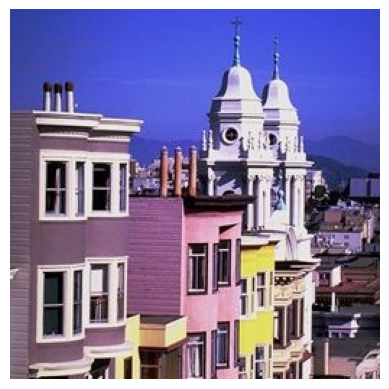

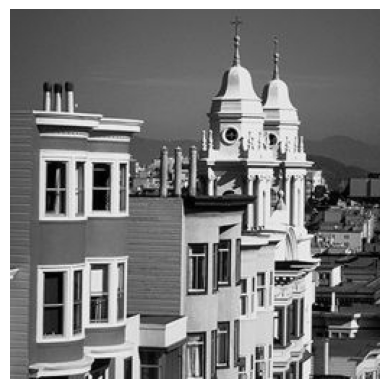

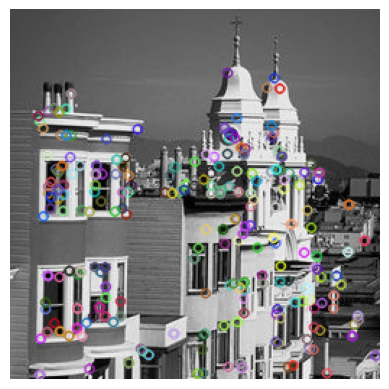

In [8]:
img = cv2.imread('./BOW_data/train/inside_city/a48009.jpg')
cv2_imshow(img)

gray= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

#SIFTdetector = cv2.xfeatures2d.SIFT_create(nfeatures=300)

SIFTdetector = cv2.SIFT_create(300)
kpt=SIFTdetector.detect(gray,None)
img2=cv2.drawKeypoints(gray,kpt,img)
cv2_imshow(img)

Now we start to create the dictionary of visual words by detecting keypoints and computing the SIFT descriptors for all the training images

In [10]:
Train_descriptors = []
Train_label_per_descriptor = []
for filename,labels in zip(train_filenames,train_labels):
    ima=cv2.imread('./BOW_data/' +  filename)
    gray=cv2.cvtColor(ima,cv2.COLOR_BGR2GRAY)
    kpt,des=SIFTdetector.detectAndCompute(gray,None)
    Train_descriptors.append(des)
    Train_label_per_descriptor.append(labels)

D=np.vstack(Train_descriptors)

Next, we apply k-means clustering on the descriptor space. The cluster centers form the dictionary of visual words.

We will use `MiniBatchKMeans`, a variant of the KMeans algorithm which uses mini-batches to reduce the computation time.

`n_clusters` is the number of clusters or visual words in the dictionary. You can change this value to see the efect of using bigger or smaller dictionaries.

In [11]:
k = 128
codebook = MiniBatchKMeans(n_clusters=k, verbose=False, batch_size=k * 20,compute_labels=False,reassignment_ratio=10**-4,random_state=42,n_init=3)
codebook.fit(D)
codebook.cluster_centers_

array([[ 29.823593 ,  33.98231  ,  16.700855 , ...,   4.18162  ,
          3.3001378,   7.592229 ],
       [ 25.54786  ,  36.628334 ,  25.807785 , ...,  59.619366 ,
         18.519224 ,   8.485434 ],
       [ 40.90836  ,  19.902716 ,  11.549851 , ...,  25.977716 ,
         18.218473 ,  16.198988 ],
       ...,
       [ 80.60404  ,  25.7575   ,   7.533892 , ...,  14.454125 ,
         15.622762 ,   9.060712 ],
       [ 21.908371 ,  19.953964 ,  18.322897 , ...,   6.902474 ,
          7.779766 ,  14.712195 ],
       [106.06851  ,  33.438457 ,   6.252037 , ...,  11.836403 ,
          9.209269 ,  12.609132 ]], dtype=float32)

For each training image, we project each keypoint descriptor to its closest visual word. We represent each of the images with the frequency of each visual word.

In [12]:
visual_words=np.zeros((len(Train_descriptors),k),dtype=np.float32)
for i in range(len(Train_descriptors)):
    words=codebook.predict(Train_descriptors[i])
    visual_words[i,:]=np.bincount(words,minlength=k)

We create a k-nn classifier and train it with the training set histograms (Note that we use 'knn = KNeighborsClassifier`to create the classifier, and knn.fit for t

In [13]:
knn = KNeighborsClassifier(n_neighbors=5,n_jobs=-1,metric='euclidean')
knn.fit(visual_words, train_labels)

KNeighborsClassifier(metric='euclidean', n_jobs=-1)

We compute the histograms for the test images, classify and compute the accuracy

In [14]:
visual_words_test=np.zeros((len(test_filenames),k),dtype=np.float32)
for i in range(len(test_filenames)):
    filename=test_filenames[i]
    ima=cv2.imread('./BOW_data/' +filename)
    gray=cv2.cvtColor(ima,cv2.COLOR_BGR2GRAY)
    kpt,des=SIFTdetector.detectAndCompute(gray,None)
    words=codebook.predict(des)
    visual_words_test[i,:]=np.bincount(words,minlength=k)

In [15]:
print ('example of a histogram of visual words (representation of image i):')
print (visual_words_test[0,:])

example of a histogram of visual words (representation of image i):
[ 3.  0.  3.  1.  2.  4.  0.  4.  2.  0.  8.  1.  3.  4.  1.  1.  3.  0.
  1.  1.  1.  0.  0.  3.  0.  2.  0.  0.  2.  1.  2.  2.  8.  0.  2.  5.
  0.  2.  0.  3.  1.  1.  3.  0.  1.  2.  1.  4.  1.  0.  0.  1.  0.  2.
  0.  0.  0. 10.  4.  3.  0.  1.  2.  0.  2.  5.  5.  0.  0.  2.  2.  1.
  2.  7.  2.  3.  2.  2.  0.  7.  0.  0.  0.  2.  1.  3.  0.  3.  3.  3.
  3.  0.  2.  4.  1.  3.  3.  3.  5.  0.  2.  0.  1.  0.  2.  2.  2.  3.
  0.  1.  1.  1.  2.  8.  3.  0.  0.  1.  4.  0.  5.  1.  1.  3.  8.  0.
  1.  2.]


In [16]:
accuracy = 100*knn.score(visual_words_test, test_labels)
print(accuracy)

predicted_labels = knn.predict(visual_words_test)
accuracy2 = accuracy_score(test_labels, predicted_labels)
print(accuracy2)

54.15117719950434
0.5415117719950434


## Tasks



1. Compute the confusion matrix and balanced accuracy. Which are the easiest and the most difficult classes? (import confusion_matrix or plot_confusion_matrix and balanced_accuracy_score from sklearn.metrics)
2. Test different codebook sizes and different values of neighbors in k-NN. Compare and report your best results.
3. Use a linear SVM classifier (use sklearn StandardScaler to standardize features).
4. (Optional) Use another variant of SVM: (1) with RBF kernel, (2) with histogram intersection kernel.
Use sklearn `StandardScaler` to standardize features.
5. Use Dense SIFT instead of detected keypoints. Report your best results and compare with results using detected keypoints.
6. Conclusions: Write a few paragraphs summarizing your work, results and conclusions from this assignment






<font color=red>1.   Compute the confusion matrix and balanced accuracy. Which are the easiest and the most difficult classes?

Import `confusion_matrix` or `plot_confusion_matrix` and `balanced_accuracy_score` from sklearn.metrics)</font><br>

In [ ]:
conf_m = confusion_matrix(test_labels, predicted_labels) 
print(conf_m)
report = classification_report(test_labels, predicted_labels) 
print(report)
balanced_acc = balanced_accuracy_score(test_labels, predicted_labels)
print(balanced_acc)

[[47 13 17 15  0 20  6  0]
 [16 79  0  8  0 10  2  1]
 [12  1 80  0  0  8  0  0]
 [ 2 22  0 46  0  1  4  1]
 [ 3  4  3  8 51  0 18  7]
 [23 15  8  4  0 60  4  0]
 [ 7  3  2  8  8  3 42  7]
 [13 10  4 16 11  5 17 32]]
              precision    recall  f1-score   support

 Opencountry       0.38      0.40      0.39       118
       coast       0.54      0.68      0.60       116
      forest       0.70      0.79      0.74       101
     highway       0.44      0.61      0.51        76
 inside_city       0.73      0.54      0.62        94
    mountain       0.56      0.53      0.54       114
      street       0.45      0.53      0.49        80
tallbuilding       0.67      0.30      0.41       108

    accuracy                           0.54       807
   macro avg       0.56      0.55      0.54       807
weighted avg       0.56      0.54      0.54       807

0.5458559013224068


<font color=white>
The easiest class we have is Forest with a 0.74 F1-score, followed by Inside city 0.62 and Coast with 0.6. For the more difficult classes to predict, we have Opencountry with an F1-score of 0.39, then Tallbuilding with 0.41 and street with 0.49
</font><br>

<font color=red>2.   Test different codebook sizes and different values of neighbors in k-NN.

Compare and report your best results. You can also try using different distances.</font><br>

In [24]:
# Your code here
def compute_codebook(k, knn_n):
    print(f"Running with codebook size {k} and k-nn neighbours {knn_n}")
    codebook = MiniBatchKMeans(n_clusters=k, verbose=False, batch_size=k * 20,compute_labels=False,reassignment_ratio=10**-4,random_state=42,n_init=3)
    codebook.fit(D)
    codebook.cluster_centers_
    
    visual_words=np.zeros((len(Train_descriptors),k),dtype=np.float32)
    for i in range(len(Train_descriptors)):
        words=codebook.predict(Train_descriptors[i])
        visual_words[i,:]=np.bincount(words,minlength=k)
        
    knn = KNeighborsClassifier(n_neighbors=knn_n,n_jobs=-1,metric='euclidean')
    knn.fit(visual_words, train_labels)    
    
    visual_words_test=np.zeros((len(test_filenames),k),dtype=np.float32)
    for i in range(len(test_filenames)):
        filename=test_filenames[i]
        ima=cv2.imread('./BOW_data/' +filename)
        gray=cv2.cvtColor(ima,cv2.COLOR_BGR2GRAY)
        kpt,des=SIFTdetector.detectAndCompute(gray,None)
        words=codebook.predict(des)
        visual_words_test[i,:]=np.bincount(words,minlength=k)     
    predicted_labels = knn.predict(visual_words_test)   
    
    conf_m = confusion_matrix(test_labels, predicted_labels) 
    print(conf_m)
    report = classification_report(test_labels, predicted_labels) 
    print(report)
    balanced_acc = balanced_accuracy_score(test_labels, predicted_labels)
    print(balanced_acc)
    print("#"*10)


for k in [64, 128, 256]:
    for knn_n in [1, 3, 5]:
        compute_codebook(k, knn_n)

Running with codebook size 64 and k-nn neighbours 1
[[46 12  9 10  1 25 12  3]
 [18 66  0 12  1 14  5  0]
 [24  0 54  0  0 20  3  0]
 [ 8 22  0 33  1  4  3  5]
 [ 5  3  2 12 35  1 22 14]
 [22  6 10  9  4 52  8  3]
 [ 9  3  4  1 10  6 37 10]
 [10 12  5  3 10  5 22 41]]
              precision    recall  f1-score   support

 Opencountry       0.32      0.39      0.35       118
       coast       0.53      0.57      0.55       116
      forest       0.64      0.53      0.58       101
     highway       0.41      0.43      0.42        76
 inside_city       0.56      0.37      0.45        94
    mountain       0.41      0.46      0.43       114
      street       0.33      0.46      0.39        80
tallbuilding       0.54      0.38      0.45       108

    accuracy                           0.45       807
   macro avg       0.47      0.45      0.45       807
weighted avg       0.47      0.45      0.45       807

0.44978380292712716
##########
Running with codebook size 64 and k-nn neighbours

<font color=blue>2. Answer:  </font><br>


<font color=red>3. Use a linear SVM classifier. Use sklearn `StandardScaler` to standardize features (removing the mean and scaling to unit variance).</font><br>

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC   
   

# Your code here to compute the codebook and histograms for training images

codebook = MiniBatchKMeans(n_clusters=k, verbose=False, batch_size=k * 20,compute_labels=False,reassignment_ratio=10**-4,random_state=42,n_init=3)
codebook.fit(D)
visual_words=np.zeros((len(Train_descriptors),k),dtype=np.float32)
for i in range(len(Train_descriptors)):
    words=codebook.predict(Train_descriptors[i])
    visual_words[i,:]=np.bincount(words,minlength=k)
# Your code here to compute the histograms for the test images
visual_words_test=np.zeros((len(test_filenames),k),dtype=np.float32)
for i in range(len(test_filenames)):
    filename=test_filenames[i]
    ima=cv2.imread('./BOW_data/' +filename)
    gray=cv2.cvtColor(ima,cv2.COLOR_BGR2GRAY)
    kpt,des=SIFTdetector.detectAndCompute(gray,None)
    words=codebook.predict(des)
    visual_words_test[i,:]=np.bincount(words,minlength=k)     
predicted_labels = knn.predict(visual_words_test)   

# Use StandardScaler to standardize features
scaler=StandardScaler()
scaler.fit(visual_words)
vw_train_sc= scaler.transform(visual_words)
vw_test_sc = scaler.transform(visual_words_test)

# Create and fit a svm classifier
svm = SVC(kernel='linear')
svm.fit(vw_train_sc, train_labels)

# Your code here to predict labels and compute metrics

predicted_labels = svm.predict(vw_test_sc)

conf_m = confusion_matrix(test_labels, predicted_labels) 
print(conf_m)
report = classification_report(test_labels, predicted_labels) 
print(report)
balanced_acc = balanced_accuracy_score(test_labels, predicted_labels)
print(balanced_acc)


<font color=blue>3. Answer:  </font><br>

<font color=red>4. (optional) Use another variant of SVM: (1) with RBF kernel, (2) with histogram intersection kernel.
Use sklearn `StandardScaler` to standardize features.</font><br>

In [ ]:
svm = SVC(kernel='rbf')
svm.fit(vw_train_sc, train_labels)

# Your code here to predict labels and compute metrics

predicted_labels = svm.predict(vw_test_sc)

conf_m = confusion_matrix(test_labels, predicted_labels) 
print(conf_m)
report = classification_report(test_labels, predicted_labels) 
print(report)
balanced_acc = balanced_accuracy_score(test_labels, predicted_labels)
print(balanced_acc)

In [ ]:
def histogram_intersection_kernel(X, Y):
    # TODO: Change this
    return np.sum(np.minimum(X[:, np.newaxis], Y), axis=2)


# Compute the kernel matrices
K_train = histogram_intersection_kernel(visual_words_train_sc, visual_words_train_sc)
K_test = histogram_intersection_kernel(
    visual_words_test_sc, visual_words_train_sc
)  # Test vs train

# SVM with precomputed kernel
svm_hist = SVC(kernel="precomputed")
svm_hist.fit(K_train, train_labels)

# Predict and evaluate
predictions_hist = svm_hist.predict(K_test)
acc_hist = 100 * accuracy_score(test_labels, predictions_hist)
bal_acc_hist = 100 * balanced_accuracy_score(test_labels, predictions_hist)

plot_confusion_matrix(test_labels, predictions_hist, classes=np.unique(test_labels))
print(f"SVM (Histogram Intersection Kernel) Accuracy: {acc_hist:.2f}%")
print(f"SVM (Histogram Intersection Kernel) Balanced Accuracy: {bal_acc_hist:.2f}")

<font color=blue>4. Answer:  </font><br>

<font color=red>5. Use Dense SIFT instead of detected keypoints. Report your best results and compare with results using detected keypoints.</font><br>


<font color=blue>5. Answer:  </font><br>

<font color=blue>Conclusions:

Write a few paragraphs summarizing your work, results and conclussions from this assignment</font><br>

